# HW2 - Classification Pipeline and Performance Evaluation

## Table of Contents

1. Dataset Exploration
2. Data Preprocessing
3. Feature Scaling
4. Train-Test Split
5. Logistic Regression
6. k-Nearest Neighbors
7. Decision Tree
8. Performance Evaluation
9. Confusion Matrix Analysis
10. Cross Validation
11. Overfitting & Underfitting Analysis
12. Final Discussion
13. Conclusion

### 1 — Dataset Exploration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use('ggplot')

### Objective:

The objective of this section is to explore the Breast Cancer Wisconsin dataset and understand its structure, feature types, target classes, and overall characteristics before applying machine learning algorithms.

### Method:

The dataset is loaded using the scikit-learn library. Basic exploratory analysis is performed to examine:

* number of samples
* number of features
* target classes
* feature types
* dataset structure

This step helps identify preprocessing requirements and provides a better understanding of the classification problem.

In [3]:
cancer = load_breast_cancer()

In [4]:
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df['target'] = cancer.target

In [5]:
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [6]:
print(df.shape)

(569, 31)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Result:

The dataset contains 569 samples and 30 numerical input features extracted from digitized images of breast mass cell nuclei.

The target variable represents two classes:

* Malignant
* Benign

All input features are continuous numerical variables.

### Interpretation:

The dataset is clean and well-structured for binary classification tasks.

Since all features are numerical, classical machine learning algorithms such as Logistic Regression, kNN, and Decision Trees can be applied effectively.

The dataset size is relatively moderate, making it suitable for experimentation, evaluation, and visualization.

In [8]:
print(cancer.target_names)

['malignant' 'benign']


In [9]:
df['target'].value_counts()

,count
target,
1,357
0,212


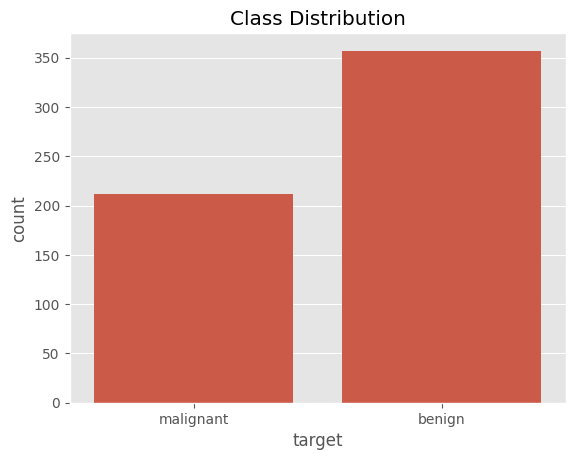

In [10]:
sns.countplot(x='target', data=df)
target_names = cancer.target_names
plt.xticks(ticks=[0, 1], labels=target_names)
plt.title("Class Distribution")
plt.show()

### Interpretation of Class Distribution

The dataset is relatively balanced, although benign samples appear slightly more frequently than malignant samples.

Class balance is important because highly imbalanced datasets may bias classifiers toward the majority class and produce misleading accuracy scores.

### 2 - Missing Values & Preprocessing

### Objective:

The objective of this section is to investigate whether the dataset contains missing values or requires preprocessing before model training.

### Method:

The dataset is checked for missing values using pandas functions.

Detecting missing values is important because many machine learning algorithms cannot handle incomplete data directly.

In [11]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


### Result:

The dataset does not contain any missing values.

All features are complete and usable for machine learning analysis.

### Interpretation:

Since the dataset is clean and contains no missing values, no imputation techniques are required.

Therefore, preprocessing mainly focuses on feature scaling and train-test splitting.

### 3 - Feature Scaling

In [12]:
X = df.drop('target', axis=1)
y = df['target']

### * Train-Test Split

### Objective:

The objective of this section is to divide the dataset into separate training and testing subsets.

This allows the models to be trained on one portion of the data and evaluated on unseen samples.

### Method:

The dataset is divided using an 80%-20% split:

* 80% training data
* 20% testing data

A fixed random_state is used to ensure reproducibility.

Stratification is also applied to preserve the class distribution in both subsets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Interpretation:

Using a separate test dataset allows a more realistic evaluation of model generalization performance.


### * feature scaling

### Objective

The objective of feature scaling is to transform features into a similar numerical range so that machine learning algorithms can treat all features fairly during training.


### Why Feature Scaling is Important

Some machine learning algorithms are highly sensitive to feature magnitudes.

For example:

* k-Nearest Neighbors (kNN) uses distance calculations.
* Logistic Regression uses gradient-based optimization.

If one feature has much larger values than others, it may dominate the learning process and negatively affect model performance.

Decision Trees are generally less sensitive to feature scaling because they split data based on thresholds rather than distances.


### Method

In this project, StandardScaler was used to standardize the dataset.

Standardization transforms features so that:

* Mean = 0
* Standard Deviation = 1

This helps improve numerical stability and model performance.

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Interpretation

Feature scaling is expected to improve the performance of distance-based algorithms such as kNN.

It may also help Logistic Regression converge more efficiently during optimization.

The effect of scaling on Decision Trees is expected to be minimal.

### 4 - Logistic Regression

### Objective:

The objective of this section is to train a Logistic Regression classifier and evaluate its classification performance on the breast cancer dataset.

### Method:

The model is trained using the standardized training dataset.

Logistic Regression is a linear classification algorithm that estimates the probability of class membership using a sigmoid function.

Feature scaling is important for Logistic Regression because the optimization process is sensitive to feature magnitudes.

In [15]:
lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

#### Prediction

In [16]:
y_pred_lr = lr_model.predict(X_test_scaled)

Accuracy

In [17]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9824561403508771


### Result:

The Logistic Regression classifier achieved a high classification accuracy on the test dataset.

### Interpretation:

The strong performance indicates that the dataset contains meaningful patterns that can be separated effectively using a linear decision boundary.

The model also demonstrates good generalization capability on unseen data.

### 5 - kNN

### Objective:

The objective of this section is to train and analyze a k-Nearest Neighbors classifier using different k values.

### Method:

kNN classifies samples based on the majority class among neighboring data points.

Different k values are tested to investigate how model complexity affects classification performance.

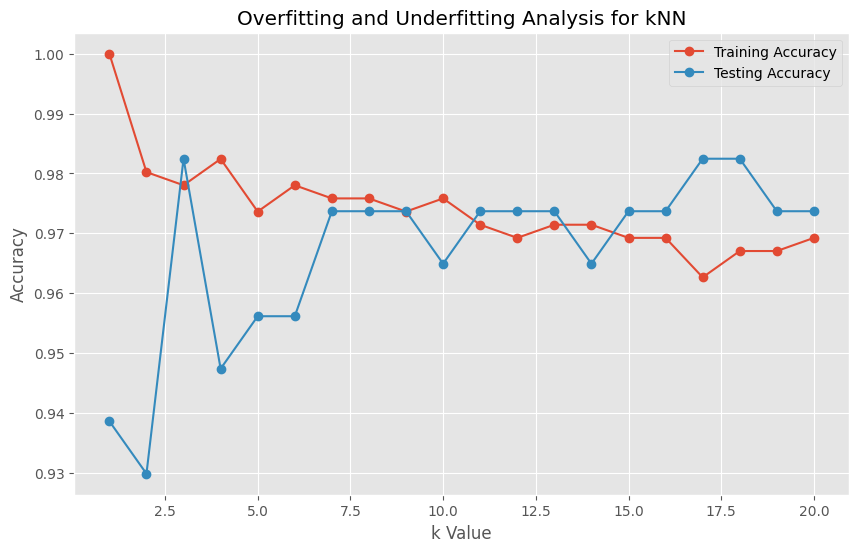

In [31]:
k_values = range(1, 21)

train_scores = []
test_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    train_scores.append(
        knn.score(X_train_scaled, y_train)
    )

    test_scores.append(
        knn.score(X_test_scaled, y_test)
    )

plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    k_values,
    test_scores,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel("k Value")
plt.ylabel("Accuracy")
plt.title("Overfitting and Underfitting Analysis for kNN")

plt.legend()

plt.show()

### Result:

The graph shows how training and testing accuracy change as the value of "k" increases.


### Interpretation:

Very small k values may lead to overfitting because the classifier becomes highly sensitive to noise and local patterns.

Very large k values may lead to underfitting because the decision boundary becomes overly smooth.

An intermediate k value provides the best generalization performance.

In [20]:
best_knn = KNeighborsClassifier(n_neighbors=5)

best_knn.fit(X_train_scaled, y_train)

y_pred_knn = best_knn.predict(X_test_scaled)

### Final kNN Evaluation

The selected k value achieved strong classification performance on the test dataset.

This demonstrates the importance of hyperparameter tuning in machine learning models.

### 6 - Decision Tree

### Objective:

The objective of this section is to analyze how tree depth affects Decision Tree classification performance.

### Method:

Decision Trees classify data by recursively splitting features into decision rules.

Different tree depths are tested to investigate model complexity and generalization ability.

In [21]:
depths = range(1, 11)

train_acc = []
test_acc = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train, y_train)

    train_acc.append(dt.score(X_train, y_train))
    test_acc.append(dt.score(X_test, y_test))

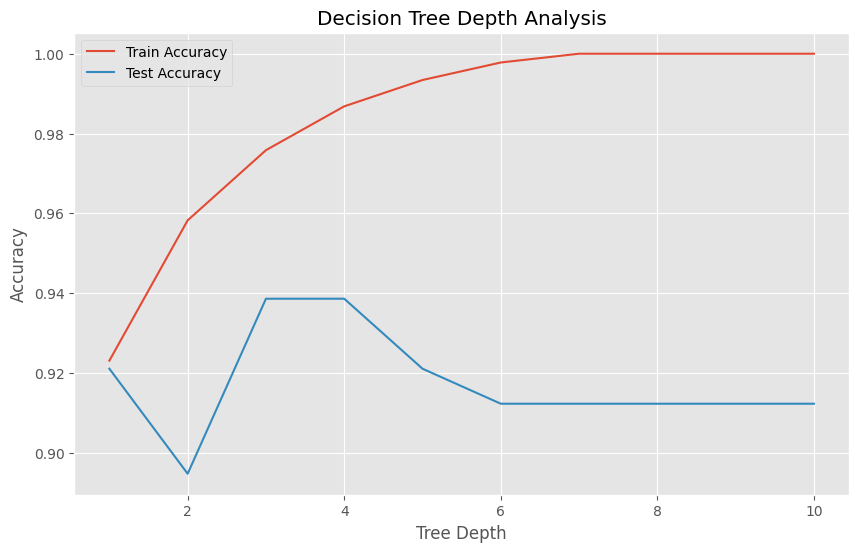

In [22]:
plt.figure(figsize=(10,6))

plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth Analysis")

plt.legend()
plt.show()

### Result:

The graph illustrates how training and testing accuracy vary across different tree depths.
The selected Decision Tree achieved strong classification performance while maintaining reasonable generalization capability.
Controlling tree depth helps reduce overfitting risk.

### Interpretation:

Shallow trees may underfit because they cannot capture complex patterns in the dataset.

Very deep trees may overfit by memorizing training samples instead of learning generalized patterns.

An optimal tree depth provides the best balance between bias and variance.

### 7 - Evaluation Metrics

### Objective

The objective of this section is to evaluate classifier performance using multiple evaluation metrics.

### Method

The following metrics are computed:

* Accuracy
* Precision
* Recall
* F1-score

Each metric provides different insights into classification behavior.

In [23]:
def evaluate_model(y_true, y_pred, model_name):

    print(f"\n{model_name}")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

In [24]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_knn, "kNN")


Logistic Regression
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


kNN
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [25]:
best_dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

best_dt.fit(X_train, y_train)

y_pred_dt = best_dt.predict(X_test)

evaluate_model(y_test, y_pred_dt, "Decision Tree")


Decision Tree
Accuracy: 0.9385964912280702
Precision: 0.9577464788732394
Recall: 0.9444444444444444
F1 Score: 0.951048951048951

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



### Interpretation

Accuracy alone is not sufficient in medical diagnosis applications.

In cancer detection, Recall is especially important because failing to detect malignant tumors can have serious consequences.

F1-score is also valuable because it balances Precision and Recall.

Therefore, multiple evaluation metrics must be analyzed together.

### 8 - Confusion Matrix

### Objective:

The objective of this section is to analyze classification behavior using confusion matrices.

### Method:

Confusion matrices are generated for all classifiers to evaluate:

* True Positives
* True Negatives
* False Positives
* False Negatives

This provides deeper insight into prediction behavior beyond overall accuracy.

In [26]:
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

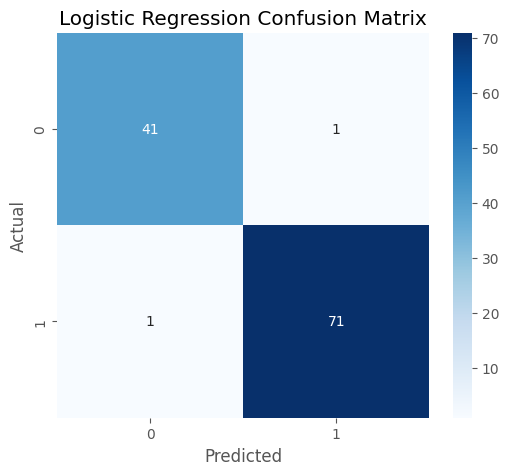

In [27]:
plot_confusion_matrix(
    y_test,
    y_pred_lr,
    "Logistic Regression Confusion Matrix"
)

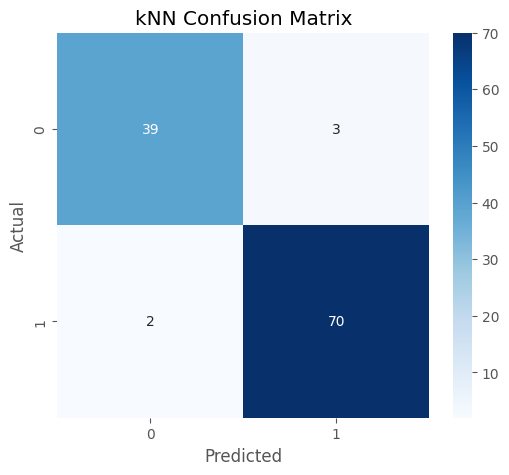

In [28]:
plot_confusion_matrix(
    y_test,
    y_pred_knn,
    "kNN Confusion Matrix"
)

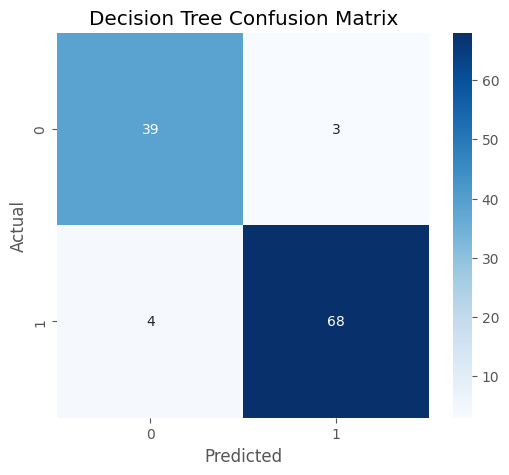

In [29]:
plot_confusion_matrix(
    y_test,
    y_pred_dt,
    "Decision Tree Confusion Matrix"
)

### Interpretation:

The confusion matrix reveals how the classifier handles different prediction categories.

* True Positives represent correctly identified malignant tumors.
* True Negatives represent correctly identified benign tumors.
* False Positives occur when benign tumors are incorrectly classified as malignant.
* False Negatives occur when malignant tumors are incorrectly classified as benign.

In medical diagnosis, False Negatives are particularly dangerous because missed cancer cases may delay treatment.

### 9 - Cross Validation

### Objective:

The objective of this section is to evaluate model stability and generalization performance using 5-fold cross-validation.

### Method:

The dataset is divided into five folds.

During each iteration:

* Four folds are used for training
* One fold is used for validation

This process is repeated five times.

In [30]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "kNN":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(max_depth=4)
}

for name, model in models.items():

    print("\n==============================")
    print(f"{name}")
    print("==============================")

    if name == "Decision Tree":

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5
        )

    else:

        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5
        )

    print("Fold Accuracies:")

    for i, score in enumerate(scores):

        print(f"Fold {i+1}: {score:.4f}")

    print(f"\nMean Accuracy: {scores.mean():.4f}")

    print(f"Standard Deviation: {scores.std():.4f}")


Logistic Regression
Fold Accuracies:
Fold 1: 0.9670
Fold 2: 0.9780
Fold 3: 0.9670
Fold 4: 1.0000
Fold 5: 0.9890

Mean Accuracy: 0.9802
Standard Deviation: 0.0128

kNN
Fold Accuracies:
Fold 1: 0.9451
Fold 2: 1.0000
Fold 3: 0.9451
Fold 4: 0.9780
Fold 5: 0.9670

Mean Accuracy: 0.9670
Standard Deviation: 0.0209

Decision Tree
Fold Accuracies:
Fold 1: 0.9341
Fold 2: 0.9231
Fold 3: 0.9011
Fold 4: 0.9341
Fold 5: 0.9670

Mean Accuracy: 0.9319
Standard Deviation: 0.0213


### Result:

Cross-validation produced multiple accuracy scores across different folds for each classifier.

Mean accuracy and standard deviation were also computed.

### Interpretation:

Cross-validation provides a more reliable estimate of model performance compared to a single train-test split.

A low standard deviation indicates stable and consistent model behavior across different subsets of data.

### 10 - Final Comparison Table

### Objective:

The objective of this section is to evaluate classifier performance using multiple evaluation metrics.

### Method:

The following metrics are computed:

* Accuracy
* Precision
* Recall
* F1-score

Each metric provides different insights into classification behavior.

In [71]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "kNN",
        "Decision Tree"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,kNN,0.956140,0.958904,0.972222,0.965517
2,Decision Tree,0.938596,0.957746,0.944444,0.951049


### Interpretation:

Accuracy alone is not sufficient in medical diagnosis applications.

In cancer detection, Recall is especially important because failing to detect malignant tumors can have serious consequences.

F1-score is also valuable because it balances Precision and Recall.

Therefore, multiple evaluation metrics must be analyzed together.

### Final Discussion

Logistic Regression achieved strong overall performance and demonstrated excellent generalization capability after feature scaling.

kNN produced highly competitive results; however, its performance was strongly influenced by the choice of k value and feature scaling.

Decision Trees provided strong interpretability and visualization capability, but deep trees showed clear overfitting behavior.

Feature scaling significantly improved the performance of Logistic Regression and kNN, while its effect on Decision Trees remained limited.

Cross-validation results confirmed that the models were generally stable across different data splits.

Each classifier has unique strengths and weaknesses:

* Logistic Regression is simple, efficient, and highly interpretable.
* kNN is intuitive and effective but computationally expensive for large datasets.
* Decision Trees are easy to visualize but highly sensitive to model complexity.

### 11 - Final Conclusion

Through this project, several important machine learning concepts were explored, including preprocessing, feature scaling, model training, evaluation metrics, cross-validation, and overfitting analysis.

The experiments demonstrated that preprocessing and proper model selection significantly affect classification performance and generalization ability.

Among all classifiers, Logistic Regression achieved the best balance between:

* accuracy
* simplicity
* computational efficiency
* generalization capability

For deployment in a real-world medical classification system, Logistic Regression would be the preferred model because of its stable performance, interpretability, and strong predictive capability.

The project also highlighted the importance of evaluation metrics such as Recall and F1-score in medical diagnosis tasks, where minimizing false negatives is critically important.